In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

# device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [6]:
from pathlib import Path
names_path = Path('/content/names.txt')
if not names_path.exists():
    !wget -q https://raw.githubusercontent.com/karpathy/makemore/master/names.txt -O /content/names.txt

In [7]:
# read in all the words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [8]:
# build the vocabulary of characters and mapping to/from integers

chars = sorted(list(set(''.join(words)))) 
stoi = {
    s:i+1 for i,s in enumerate(chars)
}
stoi['.'] =0
itos = {
    i:s for s,i in stoi.items()
}

vocab_size = len(stoi)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [9]:
# Building the dataset 

block_size = 3

def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y



In [10]:
# Spliting data into train, dev and test sets

import random
random.seed()

random.shuffle(words)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xtest , Ytest = build_dataset(words[n2:])


torch.Size([182537, 3]) torch.Size([182537])
torch.Size([22747, 3]) torch.Size([22747])
torch.Size([22862, 3]) torch.Size([22862])


In [11]:
# MLP revisted

n_embd = 10 # the dimensionality of the character embedding words
n_hidden = 200 # the numder fo neurons in the hidden layer of the MLP


g = torch.Generator().manual_seed(2147483647)
c = torch.randn((vocab_size , n_embd), generator=g)


W1 = torch.randn((n_embd * block_size , n_hidden), generator=g) * ((5/3) / ((n_embd* block_size)**(0.5)))

b1 = torch.randn(n_hidden, generator=g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0 


parameters = [c, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [12]:
W1.shape , b1.shape , W2.shape , b2.shape


(torch.Size([30, 200]),
 torch.Size([200]),
 torch.Size([200, 27]),
 torch.Size([27]))

In [13]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = c[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())




      0/ 200000: 3.3407
  10000/ 200000: 2.3532
  20000/ 200000: 2.0539
  30000/ 200000: 2.1182
  40000/ 200000: 2.2129
  50000/ 200000: 1.8182
  60000/ 200000: 2.2110
  70000/ 200000: 1.5920
  80000/ 200000: 2.1048
  90000/ 200000: 1.6038
 100000/ 200000: 2.2094
 110000/ 200000: 2.4999
 120000/ 200000: 2.0954
 130000/ 200000: 2.0623
 140000/ 200000: 2.2404
 150000/ 200000: 2.0491
 160000/ 200000: 2.0768
 170000/ 200000: 1.8842
 180000/ 200000: 1.8702
 190000/ 200000: 2.3216


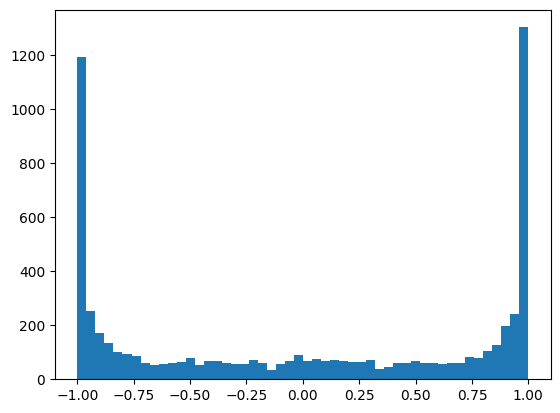

In [14]:
plt.hist(h.view(-1).tolist() , 50);

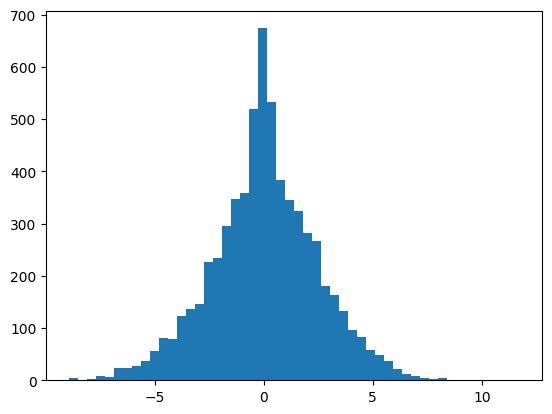

In [15]:
plt.hist(hpreact.view(-1).tolist() , 50);

# Understanding

During the training of our neural network we see the initial loss of our network is too high


In training of neural network we often have a rough idea about what should be the possible loss at initilization that depends on the loss function and the problem setter

## What should be the possible loss at initilization

During initilization we dont have to belive that any other charcter is much more likely than other , we need a uniform distribution 

Assigning equal probality of each characters

Probality of each character is 1/27 = 0.037 

`-torch.tesnor(1/27).log()` = 3.2958


```
    0/ 200000: 25.3398
    10000/ 200000: 3.3337
```


## 2. Issue: Tanh Saturation (Saturated Neurons)

**Tanh** is a squashing function: it maps any real number into the range (-1, 1).

Same setup as in our micrograd chapter:

```
hpreact = embcat @ W1 + b1   # hidden layer pre-activation (linear step)
h = tanh(hpreact)            # hidden layer output (after activation)
```

- `embcat` is the flattened input vector (3 character embeddings concatenated)
- `hpreact[j]` is the weighted sum + bias for hidden neuron `j`, before tanh
- `h` is the output **after** tanh

### What is the problem?

Every `h` is always between -1 and 1 — that is normal. The problem is **saturation at the endpoints**.

With default `torch.randn` init for `W1` and `b1`, each `hpreact` is a sum of ~30 random terms, so values are often large (e.g. ±5, ±10). That pushes `h = tanh(hpreact)` very close to **+1 or -1**, not near 0.

| hpreact (z) | h = tanh(z) | gradient 1 - h² |
|-------------|-------------|-----------------|
| ~0          | ~0          | ~1 (healthy)    |
| +5          | ~0.999      | ~0.002 (tiny)   |
| -8          | ~-1.0       | ~0 (saturated)  |

The histograms above show this: `hpreact` is spread out widely, while `h` piles up near ±1.

### Backprop through tanh (same as micrograd)

```
hpreact.grad = (1 - h²) * h.grad
```

When saturated, `h ≈ ±1`:

```
1 - h² ≈ 1 - 1 = 0
→ hpreact.grad ≈ 0 * h.grad = 0
```

So the upstream gradient gets multiplied by nearly zero — learning through those hidden units is blocked at initialization.




# Batch normalization

In [16]:
torch.tensor(1/27).log()

tensor(-3.2958)

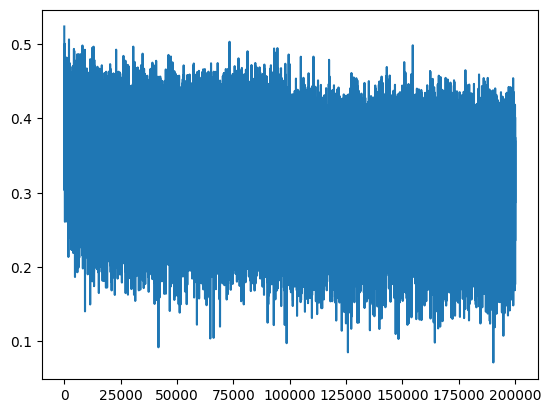

In [17]:
plt.plot(lossi)

In [18]:
@torch.no_grad()

def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xtest, Ytest)
    }[split]
    emb = c[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split}: {loss.item():.4f}")

split_loss("train")
split_loss("dev")
split_loss("test")

train: 2.0380
dev: 2.1110
test: 2.1131


# Optimization results

1. The network is too confident in the start  

```
    train: 2.1369
    dev: 2.1534
    test: 2.1897

```

2. Correctly configure the network at initlization
```
    train: 2.0719
    dev: 2.1133
    test: 2.1470
```

3. Fixing the tanh saturation

```
    train: 2.0380
    dev: 2.1110
    test: 2.1131
```

4. Batch Normalization

```
```

In [19]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural net
        emb = c[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khylmri.
ree.
cassanden.
jazonte.
deliah.
jareen.
nellara.
chaily.
kaleigh.
ham.
join.
quinn.
sulisea.
jadiquison.
madiarynn.
jaxen.
dus.
brey.
